# Scenario I [UNSW]

Figures and results for scenario II with UNSW gear crack data. Model trained with AGFD & MCC5 data


In [1]:
import glob
import os
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import torch
import torch.nn.functional as F
from einops import rearrange, reduce, repeat
from matplotlib import pyplot as plt
from scipy.stats import mode

from src.data.preprocessing_individual import get_important_frequencies
from src.data.signal_analysis import fold
from src.models.models import setup_model
from src.utils.init import setup_device

|                 | UNSW | AGFD | MCC5 |
| --------------- | ---- | ---- | ---- |
| **AGFD + MCC5** | 95.8 | -    | -    |
| **UNSW + MCC5** | -    | 89.4 | -    |
| **UNSW + AGFD** | -    | -    | 63.1 |
| **UNSW**        | -    | 88.1 | 66.7 |
| **AGFD**        | 89.6 | -    | 49.4 |
| **MCC5**        | 78.3 | 85.7 | -    |


## Setup


### Config


In [2]:
# SETUP

UNSW_teeth = 27
AGFD_teeth = 15
MCC5_teeth = 36

embedding_columns = ["x", "y"]

embedding_specs = {
    "normalize_embeddings": False,
    # "normalize_embeddings": True,  # XXX
    "average_anchors": True,
    # "average_batch": False,  # XXX
    "average_batch": True,
    "drop_anchor_outliers": 0,
    # "drop_batch_outliers": 0,
    "drop_batch_outliers": 5,  # XXX
}

config = {
    "use_difference": True,
    "gear_harmonics_to_include": 8,
    "gear_sideband_block_size": 5,
    # "gear_sideband_block_size": 3,  # XXX
    "embedding_len": 2,
    "model": "embedding",
    "backbone": "MlpMixer",
    "model_args": {
        "intermediate_L2": False,
        # "intermediate_L2": True,  # XXX
        # NORMAL
        # "num_layers": 4,
        # "hidden_dim": 21,
        # "tokens_mlp_dim": 16,
        # "channels_mlp_dim": 42,
        # LARGER HIDDEN
        "num_layers": 3,
        "hidden_dim": 32,
        "tokens_mlp_dim": 16,
        "channels_mlp_dim": 64,
        # TUNI
        # "num_layers": 4,
        # "hidden_dim": 18,
        # "tokens_mlp_dim": 16,
        # "channels_mlp_dim": 18,
    },
    "dropout": 0.0,
    "loss": "triplet",
    "loss_args": {
        "margin": 1.4,  # Doesn't matter during inference
        "miner": False,  # Doesn't matter during inference
    },
    "similarity": "euclidean",  # Doesn't matter during inference
    "lpnorm_embeddings_training": False,  # All of these are False to do them manually
    "center_embeddings_inference": False,
    "lpnorm_embeddings_inference": False,
}

device = setup_device(override="cpu")

model = setup_model(config, device)
model.eval()

# Trained model

model_weight_dir = Path.cwd().resolve() / "model_weights"
ensemble_weight_dir_name = "<FILL_ME>"

### Helpers


In [3]:
def remove_anchor_outliers(embeddings, num_outliers=5):
    filtered_embeddings = []
    # Calculate mean embedding
    mean_embedding = torch.mean(embeddings, dim=1, keepdim=True)

    # Calculate distances from each anchor to the mean
    distances = torch.norm(embeddings - mean_embedding, dim=2)

    # Find indices of closest anchors
    for i in range(distances.shape[0]):
        _, closest_indices = torch.topk(
            distances[i], distances.shape[1] - num_outliers, largest=False
        )
        filtered_embeddings.append(embeddings[i][closest_indices, :])

    filtered_embeddings = torch.stack(filtered_embeddings, dim=0)

    return filtered_embeddings


def remove_batch_outliers(embeddings, num_outliers=5):
    # Calculate mean embedding
    mean_embedding = torch.mean(embeddings, dim=0, keepdim=True)

    # Calculate distances from each anchor to the mean
    distances = torch.norm(embeddings - mean_embedding, dim=1)

    # Find indices of closest anchors
    _, closest_indices = torch.topk(
        distances, distances.shape[0] - num_outliers, largest=False
    )
    return embeddings[closest_indices, :]


def embed(
    samples,
    embedding_model,
    normalize_embeddings=False,
    average_anchors=False,
    average_batch=False,
    drop_anchor_outliers=0,
    drop_batch_outliers=0,
):
    assert not average_batch or average_anchors, (
        "Must average anchors if averaging batch"
    )

    assert drop_batch_outliers == 0 or average_anchors, (
        "Must average anchors if dropping batch outliers"
    )

    samples = torch.tensor(samples, device=device)

    embeddings = embedding_model(samples)

    if drop_anchor_outliers > 0:
        embeddings = remove_anchor_outliers(
            embeddings, num_outliers=drop_anchor_outliers
        )

    if average_anchors:
        embeddings = reduce(embeddings, "b n f -> b f", reduction="mean")

    if drop_batch_outliers > 0:
        embeddings = remove_batch_outliers(embeddings, num_outliers=drop_batch_outliers)

    if average_batch:
        embeddings = reduce(embeddings, "b f -> 1 f", reduction="mean")

    if normalize_embeddings:
        embeddings = F.normalize(embeddings, p=2, dim=-1)

    embeddings = embeddings.view(-1, embeddings.shape[-1])
    return embeddings.detach().numpy()


def embed_wrapper(samples, anchors, embedding_model, config, embedding_specs):
    if config["use_difference"]:
        samples = samples[:, np.newaxis, :] - anchors[np.newaxis, :, :]
    else:
        samples = samples[:, np.newaxis, :]

    embeddings = embed(samples, embedding_model, **embedding_specs)
    return pd.DataFrame(embeddings, columns=["x", "y"])


def get_samples_UNSW(df, speed, load, severity):
    samples = df[
        (df["speed"] == speed) & (df["load"] == load) & (df["severity"] == severity)
    ]
    samples = np.array(list(samples["signal"]))
    samples = samples[
        :,
        get_important_frequencies(
            UNSW_teeth,
            config["gear_harmonics_to_include"],
            config["gear_sideband_block_size"],
        ),
    ]
    samples = np.log10(samples)

    return samples


def get_samples_MCC5(df, speed, load, fault_class, severity, circulation=None):
    samples = df[
        (df["speed"] == speed)
        & (df["load"] == load)
        & (df["severity"] == severity)
        & (df["class"] == fault_class)
    ]

    # If None, take both torque and speed circulations
    if circulation is not None:
        samples = samples[(samples["circulation"] == circulation)]

    samples = np.array(list(samples["signal"]))
    samples = samples[
        :,
        get_important_frequencies(
            MCC5_teeth,
            config["gear_harmonics_to_include"],
            config["gear_sideband_block_size"],
        ),
    ]
    samples = np.log10(samples)

    return samples


def get_samples_AGFD(
    df, speed, load, fault_class, severity, installation=None, healthy_GP=None
):
    samples = df[
        (df["speed"] == speed)
        & (df["load"] == load)
        & (df["severity"] == severity)
        & (df["class"] == fault_class)
    ]

    if installation is not None:
        samples = samples[(samples["installation"] == installation)]

    if healthy_GP is not None:
        samples = samples[(samples["healthy_GP"] == healthy_GP)]

    samples = np.array(list(samples["signal"]))
    samples = samples[
        :,
        get_important_frequencies(
            AGFD_teeth,
            config["gear_harmonics_to_include"],
            config["gear_sideband_block_size"],
        ),
    ]
    samples = np.log10(samples)

    return samples

## Data


### Data UNSW


In [4]:
# Load data
UNSW_crack_df = pd.read_feather(Path.cwd() / "data" / "UNSW_gear_crack_OT_V2.feather")

# Change S crack to second healthy
UNSW_crack_severity_fix_map = {"H": "H1", "S": "H2"}
UNSW_crack_df["severity"] = UNSW_crack_df["severity"].transform(
    lambda x: UNSW_crack_severity_fix_map.get(x, x)
)

# Need only one OT method
# UNSW_crack_df = UNSW_crack_df[UNSW_crack_df["OT_method"] == "nico"]
UNSW_crack_df = UNSW_crack_df[UNSW_crack_df["OT_method"] == "signal"]

# Drop unnecessary columns
UNSW_crack_df.drop(
    columns=["OT_method", "TSA_size"],
    inplace=True,
)

UNSW_crack_df[["speed", "load", "severity"]].value_counts().sort_index()

speed  load  severity
2      0     H1           41
             H2           41
             L            41
             M            41
       5     H1           41
                        ... 
20     15    M           189
       20    H1          189
             H2          189
             L           189
             M           189
Name: count, Length: 117, dtype: int64

### Data MCC5


In [5]:
# Load data
MCC5_df = pd.read_feather(Path.cwd() / "data" / "MCC5-THU_OT_V3.feather")  # XXX
# MCC5_df = pd.read_feather(Path.cwd() / "data" / "MCC5-THU_OT_V2.feather")

# Need only one OT method
MCC5_df = MCC5_df[MCC5_df["OT_method"] == "signal"]
# Should only be 30 in this file, but just in case
MCC5_df = MCC5_df[MCC5_df["TSA_size"] == 30]

# Drop unnecessary columns
MCC5_df.drop(
    columns=["OT_method", "TSA_size"],
    inplace=True,
)
# Only use gearbox_vibration_x sensor
MCC5_df = MCC5_df[
    ["speed", "load", "severity", "class", "circulation", "gearbox_vibration_x"]  # XXX
]
MCC5_df.rename(columns={"gearbox_vibration_x": "signal"}, inplace=True)  # XXX

# Drop in-between speeds and loads
MCC5_df = MCC5_df[MCC5_df["speed"].isin([1000, 2000, 3000])]
MCC5_df = MCC5_df[MCC5_df["load"].isin([10, 20])]

# Keep only crack, wear, and healthy
MCC5_df = MCC5_df[MCC5_df["class"].isin(["crack", "wear", "healthy"])]
# MCC5_df = MCC5_df[MCC5_df["class"].isin(["broken_tooth", "wear", "healthy"])]  # XXX
# MCC5_df["class"] = MCC5_df["class"].map(
#     {
#         "broken_tooth": "crack",
#         "wear": "wear",
#         "healthy": "healthy",
#     }
# )

MCC5_df[["speed", "load", "severity", "class"]].value_counts().sort_index()

speed  load  severity  class  
1000   10    -         healthy     28
             L         crack       28
                       wear        28
             M         crack       28
                       wear        28
             S         crack       30
                       wear        28
       20    -         healthy     28
             L         crack       28
                       wear        28
             M         crack       28
                       wear        27
             S         crack       28
                       wear        28
2000   10    -         healthy    120
             L         crack      120
                       wear       120
             M         crack      120
                       wear       120
             S         crack      120
                       wear       120
       20    -         healthy    117
             L         crack      117
                       wear       118
             M         crack      118
                   

In [6]:
MCC5_df["class"].value_counts()

class
crack      2143
wear       2139
healthy     713
Name: count, dtype: int64

(28, 13)
    speed  load severity    class circulation OT_method  TSA_size                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

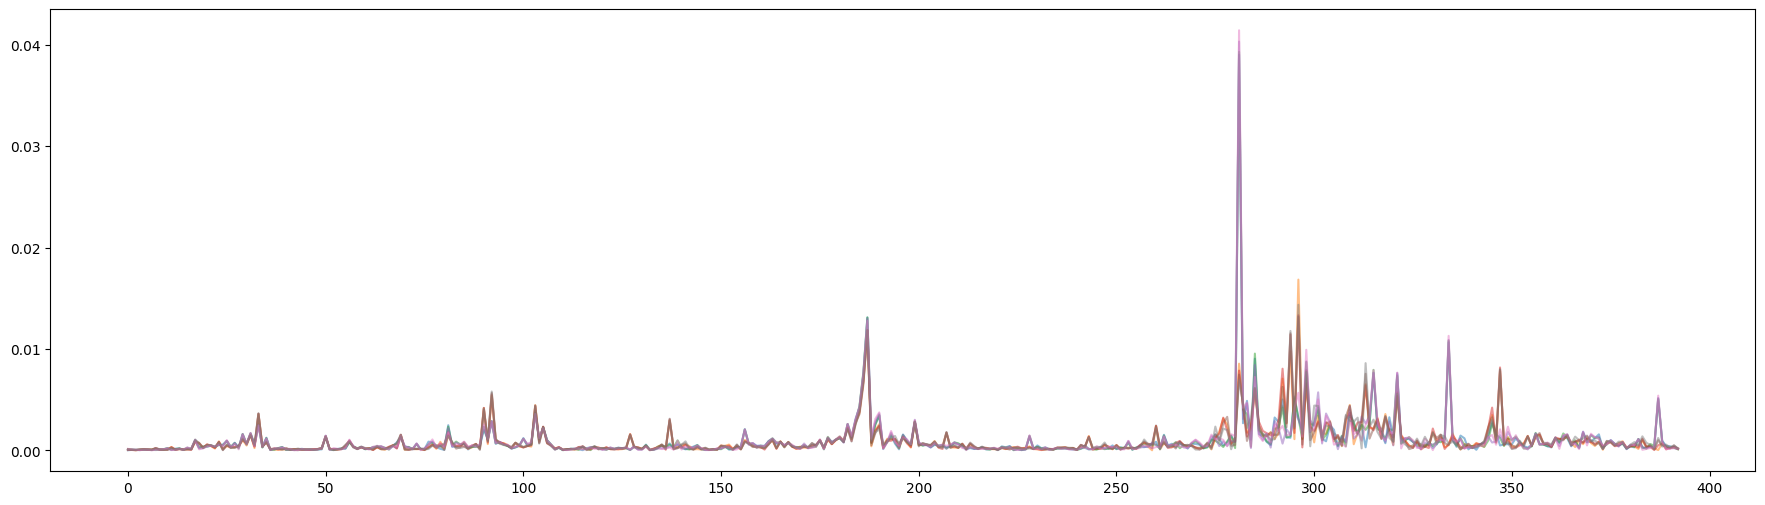

In [7]:
qwe = pd.read_feather(Path.cwd() / "data" / "MCC5-THU_OT_V3.feather")
qwe = qwe[
    (qwe["speed"] == 1000)
    & (qwe["load"] == 10)
    & (qwe["class"] == "healthy")
    # & (qwe["circulation"] == "speed")
    & (qwe["OT_method"] == "signal")
]  # ["motor_vibration_x"]
# qwe = qwe[(qwe["speed"] == 1000) & (qwe["load"] == 10) & (qwe["class"] == "healthy")]#["motor_vibration_x"]
print(qwe.shape)
print(qwe.to_string())

plt.figure(figsize=(22, 6))
for row in qwe["motor_vibration_x"][np.r_[:4, -4:]]:
    plt.plot(row[3:], alpha=0.5)

plt.show()

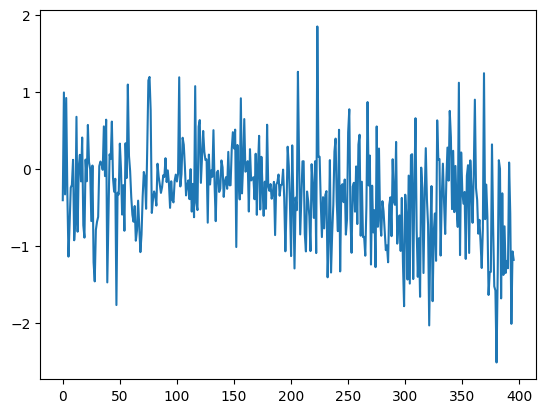

In [8]:
plt.plot(
    np.log(np.array(qwe.iloc[:10]["gearbox_vibration_x"].to_list())).mean(axis=0)
    - np.log(np.array(qwe.iloc[-10:]["gearbox_vibration_x"].to_list())).mean(axis=0)
)

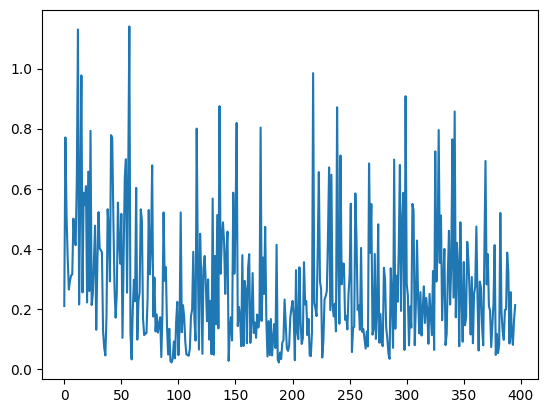

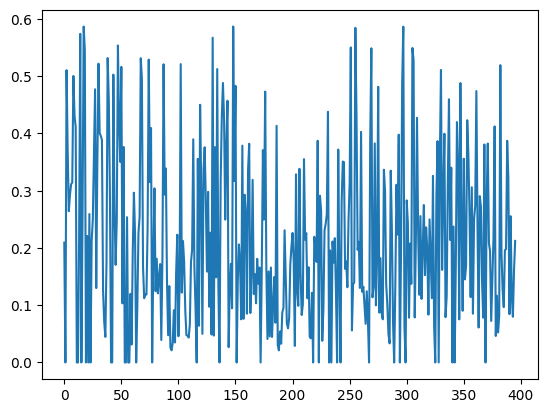

In [9]:
a = (
    np.log(np.array(qwe.iloc[-10:]["gearbox_vibration_x"].to_list()))
    - np.log(np.array(qwe.iloc[:10]["gearbox_vibration_x"].to_list())).mean(axis=0)[
        np.newaxis, :
    ]
)
a = np.std(a, axis=0)
fig = plt.plot(a)
plt.show()

plt.plot(a * (a < 0.6).astype(float))

### Data AGFD


In [10]:
# Load data
AGFD_df = pd.read_feather(Path.cwd() / "data" / "AGFD_OT_V2.feather")


# Need only one OT method
AGFD_df = AGFD_df[AGFD_df["OT_method"] == "signal"]
# Should only be 40 in this file, but just in case
AGFD_df = AGFD_df[AGFD_df["TSA_size"] == 40]

# # Drop unnecessary columns
AGFD_df.drop(
    columns=["OT_method", "TSA_size", "acc2", "acc3"],
    inplace=True,
)
# Use only Acc4
AGFD_df.rename(columns={"acc4": "signal"}, inplace=True)

# Drop 250 RPM data
AGFD_df = AGFD_df[AGFD_df["speed"] != 250]


AGFD_df[
    ["speed", "load", "class", "severity", "healthy_GP", "installation"]
].value_counts().sort_index()
# AGFD_df.value_counts().sort_index()

speed  load  class  severity  healthy_GP  installation
500    1     crack  L         0           1               300
                                          2               300
                                          3               220
                    S         0           1               300
                                          2               300
                                                         ... 
1500   11    wear   L         0           2               940
                                          3               909
                    S         0           1               940
                                          2               940
                                          3               905
Name: count, Length: 390, dtype: int64

## Results


### UNSW results


In [11]:
# Embed everything with ensemble

# ensemble_weight_dir_name = "SCENARIO_UNSW"
# ensemble_weight_dir_name = "SCENARIO_UNSW_AGFD_ONLY"
# ensemble_weight_dir_name = "SCENARIO_UNSW_A_BAGGING"
# ensemble_weight_dir_name = "SCENARIO_UNSW_MCC5_ONLY"
# ensemble_weight_dir_name = "EXPERIMENTAL_BASELINE"
# ensemble_weight_dir_name = "EXPERIMENTAL_BASELINE_PLUS"
# ensemble_weight_dir_name = "EXPERIMENTAL_A"
# ensemble_weight_dir_name = "EXPERIMENTAL_A2"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_SHALLOW"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_PERM_BLOCK"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_PERM_BLOCK_40"
# ensemble_weight_dir_name = "ASD"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_PERM_BLOCK_NOAMP"
# ensemble_weight_dir_name = "EXP_A_PERM_BLOCK_40_AMP50"  # NOTE: Last
# ensemble_weight_dir_name = "EXP_MA_PERM_BLOCK_40_AMP50"
# ensemble_weight_dir_name = "EXP_TEST_ASD"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_PERM_SC_BLOCK_40" # XXX
# ensemble_weight_dir_name = "EXPERIMENTAL_A_BLOCK_40"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_PERM"
# ensemble_weight_dir_name = "EXPERIMENTAL_SUPCON_MA"
# ensemble_weight_dir_name = "EXPERIMENTAL_SUPCON_UA"

# ensemble_checkpoint_num = 15
ensemble_checkpoint_num = 5
ensemble_size = 5

weight_files = sorted(
    list(
        glob.glob(
            str(
                model_weight_dir
                / ensemble_weight_dir_name
                / "**"
                / f"{ensemble_checkpoint_num}.pth"
            )
        )
    )
)
print(
    f"Found weight files {len(weight_files)} ({len(weight_files) / ensemble_size} ensembles)."
)

UNSW_ensemble_emb_dfs = []
for ensemble_repeat_num in range(len(weight_files) // ensemble_size):
    ensemble_weight_files = weight_files[
        ensemble_repeat_num * ensemble_size : (ensemble_repeat_num + 1) * ensemble_size
    ]

    for wf in ensemble_weight_files:
        # Load ensemble models
        model.backbone.load_state_dict(
            torch.load(
                wf,
                weights_only=True,
            )
        )
        model.eval()

        # Embeddings for one ensemble model
        all_emb_dfs = []
        for speed in [5, 10, 15, 20]:
            for load in [5, 10, 15]:
                # ANCHOR
                #

                if config["use_difference"]:
                    # * Use 16 first samples for anchors. Slowest speed has 32 samples, so it's 50% of that.
                    # * 16 from each to have consistent number of anchor samples.
                    anchor_samples = get_samples_UNSW(UNSW_crack_df, speed, load, "H1")[
                        :16
                    ]

                    anchor_samples = reduce(anchor_samples, "b w -> 1 w", "mean")
                    # anchor_samples = rearrange(anchor_samples, "(a b) w -> a b w", a=4, b=4)
                    # anchor_samples = reduce(anchor_samples, "a b w -> a w", a=4, b=4)

                # HEALTHY 1
                #

                # * Drop 16 first from H1, as those are used for anchors
                healthy_samples_1 = get_samples_UNSW(UNSW_crack_df, speed, load, "H1")[
                    16:
                ]
                healthy_emb_df_1 = embed_wrapper(
                    healthy_samples_1, anchor_samples, model, config, embedding_specs
                )
                healthy_emb_df_1["class"] = "healthy"
                healthy_emb_df_1["severity"] = "H1"

                # HEALTHY 2
                #

                healthy_samples_2 = get_samples_UNSW(UNSW_crack_df, speed, load, "H2")
                healthy_emb_df_2 = embed_wrapper(
                    healthy_samples_2, anchor_samples, model, config, embedding_specs
                )
                healthy_emb_df_2["class"] = "healthy"
                healthy_emb_df_2["severity"] = "H2"

                # CRACK 1
                #

                crack_samples_1 = get_samples_UNSW(UNSW_crack_df, speed, load, "M")
                crack_emb_df_1 = embed_wrapper(
                    crack_samples_1, anchor_samples, model, config, embedding_specs
                )
                crack_emb_df_1["class"] = "crack"
                crack_emb_df_1["severity"] = "M"

                # CRACK 2
                #

                crack_samples_2 = get_samples_UNSW(UNSW_crack_df, speed, load, "L")
                crack_emb_df_2 = embed_wrapper(
                    crack_samples_2, anchor_samples, model, config, embedding_specs
                )
                crack_emb_df_2["class"] = "crack"
                crack_emb_df_2["severity"] = "L"

                # Combine all dataframes and add back operating condition info
                emb_df = pd.concat(
                    [
                        healthy_emb_df_1,
                        healthy_emb_df_2,
                        crack_emb_df_1,
                        crack_emb_df_2,
                    ],
                    ignore_index=True,
                )
                emb_df["speed"] = speed
                emb_df["load"] = load

                all_emb_dfs.append(emb_df)

        all_emb_dfs = pd.concat(all_emb_dfs, ignore_index=True)
        UNSW_ensemble_emb_dfs.append(all_emb_dfs)

Found weight files 0 (0.0 ensembles).


In [12]:
# 1 severity for prototypes
# 1 severity for query

print("Num ensembles:", len(UNSW_ensemble_emb_dfs) / ensemble_size)

all_accuracies = []
# for offset in range(10):
for offset in range(len(UNSW_ensemble_emb_dfs) // ensemble_size):  # XXX
    UNSW_accuracies = []
    # For every operating conditions (consisting of speed and load)
    # for speed in [10]:
    #     for load in [5]:
    for speed in [5, 10, 15, 20]:
        for load in [5, 10, 15]:
            for support_severity, query_severity in [("M", "L"), ("L", "M")]:
                # Repeat with every ensemble model
                ensemble_distances = []
                for e in range(5):
                    round_df = UNSW_ensemble_emb_dfs[offset * 5 + e]  # XXX
                    round_df = round_df[
                        (round_df["speed"] == speed) & (round_df["load"] == load)
                    ]

                    # Get possible prototypes

                    healthy_prototype_H1 = (
                        round_df[round_df["severity"] == "H1"][["x", "y"]]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    crack_prototype = (
                        round_df[round_df["severity"] == support_severity][["x", "y"]]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    # Use everything else for query
                    # (Not H1 [used for anchor] and not samples from operating condition used for prototypes)
                    query_df = round_df[
                        round_df["severity"].isin([query_severity, "H2"])
                    ]

                    # Convert severities to target labels [0, 1]
                    targets = (
                        query_df["severity"].map({"H2": 0, "M": 1, "L": 1}).to_numpy()
                    )

                    query_embs = query_df[["x", "y"]].to_numpy()

                    # XXX
                    # Center embeddings
                    # proto_mean = np.mean(
                    #     [healthy_prototype_H1, crack_prototype], axis=0
                    # )
                    # healthy_prototype_H1 -= proto_mean
                    # crack_prototype -= proto_mean
                    # query_embs -= proto_mean

                    # # L2-norm embeddings
                    # healthy_prototype_H1 /= np.linalg.norm(healthy_prototype_H1)
                    # crack_prototype /= np.linalg.norm(crack_prototype)
                    # query_embs /= np.linalg.norm(query_embs, axis=1, keepdims=True)
                    # XXX

                    # Calculate query distances to prototypes
                    #   H1 always used as healthy prototype
                    #   M & L crack severities used both ways
                    distances = np.stack(
                        [
                            np.linalg.norm(
                                query_embs - healthy_prototype_H1[np.newaxis, :],
                                axis=1,
                            ),
                            np.linalg.norm(
                                query_embs - crack_prototype[np.newaxis, :], axis=1
                            ),
                        ],
                        axis=1,
                    )

                    ensemble_distances.append(distances)

                ensemble_distances = np.stack(ensemble_distances, axis=-1)
                # Soft voting
                voted_distances = np.mean(ensemble_distances, axis=-1)
                acc = np.mean(np.argmin(voted_distances, axis=1) == targets)
                # Hard voting
                # voted_targets, _ = mode(np.argmin(ensemble_distances, axis=1), axis=1)
                # acc = np.mean(voted_targets == targets)

                UNSW_accuracies.append([acc])
                print(
                    f"{speed:<2} Hz, {load:<2} Nm: \033[95m{acc:>10.2%}\033[0m ({support_severity} -> {query_severity})"
                )
                print(
                    "  ",
                    ", ".join([
                        f"{np.mean(np.argmin(ensemble_distances[:, :, i], axis=1) == targets):.1%}"
                        for i in range(5)
                    ]),
                )

    print(f"UNSW Average Accuracy: \033[92m{np.mean(UNSW_accuracies):.4%}\033[0m")
    all_accuracies.append(np.mean(UNSW_accuracies))
    # break  # XXX
print(f"All accuracies: {np.mean(all_accuracies):.4%}")

Num ensembles: 0.0
All accuracies: nan%


/Users/hamalaa14/micromamba/envs/torch3/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/hamalaa14/micromamba/envs/torch3/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


| MA      | A       | M       |
| ------- | ------- | ------- |
| 95.8333 | 93.7500 | 72.9167 |
| 95.8333 | 87.5000 | 85.4167 |
| 95.8333 | 95.8333 | 85.4167 |
| 95.8333 | 91.6667 | 79.1667 |
| 95.8333 | 87.5000 | 77.0833 |
| 95.8333 | 89.5833 | 83.3333 |
| 95.8333 | 93.7500 | 79.1667 |
| 95.8333 | 85.4167 | 68.7500 |
| 95.8333 | 87.5000 | 79.1667 |
| 95.8333 | 83.3333 | 72.9167 |
| -       | -       | -       |
| 95.8333 | 89.5833 | 78.3333 |


#### Plots


In [13]:
target_map = ["healthy", "crack"]

hp_H1 = pd.DataFrame([healthy_prototype_H1], columns=["x", "y"])
hp_H1["target"] = "healthy"
hp_H1["role_size"] = 15
hp_H1["role"] = "support"

support_healthy = round_df[round_df["severity"] == "H1"][["x", "y"]]
support_healthy["target"] = "healthy"
support_healthy["role_size"] = 1
support_healthy["role"] = "support"

cp = pd.DataFrame([crack_prototype], columns=["x", "y"])
cp["target"] = "crack"
cp["role_size"] = 15
cp["role"] = "support"

support_crack = round_df[round_df["severity"] == "L"][["x", "y"]]
support_crack["target"] = "crack"
support_crack["role_size"] = 1
support_crack["role"] = "support"

query = pd.DataFrame(query_embs, columns=["x", "y"])
query["class"] = "query"
query["target"] = [target_map[t] for t in targets]
query["role_size"] = 2
query["role"] = "query"

emb = pd.concat([query, support_healthy, support_crack, hp_H1, cp], ignore_index=True)

fig = px.scatter(
    emb,
    x="x",
    y="y",
    color="target",
    # symbol="speed",
    # symbol="load",
    symbol="role",
    size="role_size",
    # symbol="installation",
    # hover_data=["speed", "load", "class", "severity", "installation"],
    title="UNSW",
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_layout(coloraxis_colorbar=dict(yanchor="top", y=1, x=-0.15, ticks="outside"))
fig.show()

NameError: name 'healthy_prototype_H1' is not defined

#### UNSW STD


In [ ]:
# Embed everything with ensemble

# ensemble_weight_dir_name = "SCENARIO_UNSW"
# ensemble_weight_dir_name = "SCENARIO_UNSW_AGFD_ONLY"
# ensemble_weight_dir_name = "SCENARIO_UNSW_A_BAGGING"
# ensemble_weight_dir_name = "SCENARIO_UNSW_MCC5_ONLY"
# ensemble_weight_dir_name = "EXPERIMENTAL_BASELINE"
# ensemble_weight_dir_name = "EXPERIMENTAL_BASELINE_PLUS"
# ensemble_weight_dir_name = "EXPERIMENTAL_A"
# ensemble_weight_dir_name = "EXPERIMENTAL_A2"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_SHALLOW"
ensemble_weight_dir_name = "EXPERIMENTAL_A_PERM_BLOCK_40"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_PERM_SC_BLOCK"
# ensemble_weight_dir_name = "EXPERIMENTAL_A_PERM"
# ensemble_weight_dir_name = "EXPERIMENTAL_SUPCON_MA"
# ensemble_weight_dir_name = "EXPERIMENTAL_SUPCON_UA"

ensemble_checkpoint_num = 5
mask_std_threshold = 0.1

UNSW_ensemble_emb_dfs = []
for ensemble_repeat_num in range(1, 11):
    # for ensemble_repeat_num in range(1, 4): # XXX
    # ensemble_repeat_num = 2
    ensemble_weight_dirs = sorted(
        list(os.walk(model_weight_dir / ensemble_weight_dir_name))[0][1]
    )[(ensemble_repeat_num - 1) * 5 : ensemble_repeat_num * 5]

    for e in range(5):
        # Load ensemble models
        model.backbone.load_state_dict(
            torch.load(
                model_weight_dir
                / ensemble_weight_dir_name
                / ensemble_weight_dirs[e]
                / f"{ensemble_checkpoint_num}.pth",
                weights_only=True,
            )
        )
        model.eval()

        # Embeddings for one ensemble model
        all_emb_dfs = []
        for speed in [5, 10, 15, 20]:
            for load in [5, 10, 15]:
                # GET ANCHOR & H1
                # * Use 16 first samples for anchors. Slowest speed has 32 samples, so it's 50% of that.
                # * 16 from each to have consistent number of anchor samples.
                healthy_samples_1 = get_samples_UNSW(
                    UNSW_crack_df, speed, load, "H1"
                )  # [:16]
                anchor_samples = healthy_samples_1[:16]
                anchor_samples = reduce(anchor_samples, "b w -> 1 w", "mean")
                # * Drop 16 first from H1, as those are used for anchors
                healthy_samples_1 = healthy_samples_1[16:]

                # GET REST
                healthy_samples_2 = get_samples_UNSW(UNSW_crack_df, speed, load, "H2")
                crack_samples_1 = get_samples_UNSW(UNSW_crack_df, speed, load, "M")
                crack_samples_2 = get_samples_UNSW(UNSW_crack_df, speed, load, "L")

                # ANCHOR DIFFERENCE
                healthy_samples_1 = healthy_samples_1 - anchor_samples
                healthy_samples_2 = healthy_samples_2 - anchor_samples
                crack_samples_1 = crack_samples_1 - anchor_samples
                crack_samples_2 = crack_samples_2 - anchor_samples

                # CREATE MASK
                mask_H1 = np.std(healthy_samples_1, axis=0) > mask_std_threshold
                mask_CM = np.std(crack_samples_1, axis=0) > mask_std_threshold
                mask_CL = np.std(crack_samples_2, axis=0) > mask_std_threshold

                # COMBINE MASKS
                mask_CM_support = mask_H1 & mask_CM
                mask_CL_support = mask_H1 & mask_CL

                # EMBEDDINGS
                #

                # NOTE: All need to be masked in two different ways

                # HEALTHY 1 (M)
                healthy_samples_1_M = healthy_samples_1.copy()
                healthy_samples_1_M[:, mask_CM_support] = 0.0
                healthy_emb_df_1_M = pd.DataFrame(
                    embed(
                        healthy_samples_1_M[:, np.newaxis, :], model, **embedding_specs
                    ),
                    columns=["x", "y"],
                )

                healthy_emb_df_1_M["class"] = "healthy"
                healthy_emb_df_1_M["severity"] = "H1M"

                # HEALTHY 1 (L)
                healthy_samples_1_L = healthy_samples_1.copy()
                healthy_samples_1_L[:, mask_CL_support] = 0.0
                healthy_emb_df_1_L = pd.DataFrame(
                    embed(
                        healthy_samples_1_L[:, np.newaxis, :], model, **embedding_specs
                    ),
                    columns=["x", "y"],
                )
                healthy_emb_df_1_L["class"] = "healthy"
                healthy_emb_df_1_L["severity"] = "H1L"

                # HEALTHY 2
                healthy_samples_2_M = healthy_samples_2.copy()
                healthy_samples_2_M[:, mask_CM_support] = 0.0
                healthy_emb_df_2_M = pd.DataFrame(
                    embed(
                        healthy_samples_2_M[:, np.newaxis, :], model, **embedding_specs
                    ),
                    columns=["x", "y"],
                )

                healthy_emb_df_2_M["class"] = "healthy"
                healthy_emb_df_2_M["severity"] = "H2M"

                # HEALTHY 2 (L)
                healthy_samples_2_L = healthy_samples_2.copy()
                healthy_samples_2_L[:, mask_CL_support] = 0.0
                healthy_emb_df_2_L = pd.DataFrame(
                    embed(
                        healthy_samples_2_L[:, np.newaxis, :], model, **embedding_specs
                    ),
                    columns=["x", "y"],
                )
                healthy_emb_df_2_L["class"] = "healthy"
                healthy_emb_df_2_L["severity"] = "H2L"

                # CRACK 1 (when support)
                crack_samples_1_support = crack_samples_1.copy()
                crack_samples_1_support[:, mask_CM_support] = 0.0
                crack_emb_df_1_support = pd.DataFrame(
                    embed(
                        crack_samples_1_support[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                crack_emb_df_1_support["class"] = "crack"
                crack_emb_df_1_support["severity"] = "M_support"

                # CRACK 1 (when query)
                crack_samples_1_query = crack_samples_1.copy()
                crack_samples_1_query[:, mask_CL_support] = 0.0
                crack_emb_df_1_query = pd.DataFrame(
                    embed(
                        crack_samples_1_query[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                crack_emb_df_1_query["class"] = "crack"
                crack_emb_df_1_query["severity"] = "M_query"

                # CRACK 2 (when query)
                crack_samples_2_query = crack_samples_2.copy()
                crack_samples_2_query[:, mask_CM_support] = 0.0
                crack_emb_df_2_query = pd.DataFrame(
                    embed(
                        crack_samples_2_query[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                crack_emb_df_2_query["class"] = "crack"
                crack_emb_df_2_query["severity"] = "L_query"

                # CRACK 2 (when support)
                crack_samples_2_support = crack_samples_2.copy()
                crack_samples_2_support[:, mask_CL_support] = 0.0
                crack_emb_df_2_support = pd.DataFrame(
                    embed(
                        crack_samples_2_support[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                crack_emb_df_2_support["class"] = "crack"
                crack_emb_df_2_support["severity"] = "L_support"

                # Combine all dataframes and add back operating condition info
                emb_df = pd.concat(
                    [
                        healthy_emb_df_1_M,
                        healthy_emb_df_1_L,
                        healthy_emb_df_2_M,
                        healthy_emb_df_2_L,
                        crack_emb_df_1_support,
                        crack_emb_df_1_query,
                        crack_emb_df_2_support,
                        crack_emb_df_2_query,
                    ],
                    ignore_index=True,
                )
                emb_df["speed"] = speed
                emb_df["load"] = load

                all_emb_dfs.append(emb_df)

        all_emb_dfs = pd.concat(all_emb_dfs, ignore_index=True)
        UNSW_ensemble_emb_dfs.append(all_emb_dfs)

In [ ]:
# 1 severity for prototypes
# 1 severity for query

all_accuracies = []
for offset in range(10):
    # for offset in range(3):  # XXX
    UNSW_accuracies = []
    # For every operating conditions (consisting of speed and load)
    # for speed in [10]:
    #     for load in [5]:
    for speed in [5, 10, 15, 20]:
        for load in [5, 10, 15]:
            for support_severity, query_severity in [("M", "L"), ("L", "M")]:
                # for support_severity, query_severity in [("M", "L")]: # XXX

                # Repeat with every ensemble model
                ensemble_distances = []
                for e in range(5):
                    round_df = UNSW_ensemble_emb_dfs[offset * 5 + e]
                    round_df = round_df[
                        (round_df["speed"] == speed) & (round_df["load"] == load)
                    ]

                    # Get possible prototypes

                    # ? Prototype H1 depends on support severity
                    if support_severity == "M":
                        healthy_prototype_severity = "H1M"
                        healthy_query_severity = "H2M"
                        real_fault_support_severity = "M_support"
                        real_fault_query_severity = "L_query"
                    else:
                        healthy_prototype_severity = "H1L"
                        healthy_query_severity = "H2L"
                        real_fault_support_severity = "L_support"
                        real_fault_query_severity = "M_query"

                    healthy_prototype_H1 = (
                        round_df[round_df["severity"] == healthy_prototype_severity][
                            ["x", "y"]
                        ]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    crack_prototype = (
                        round_df[round_df["severity"] == real_fault_support_severity][
                            ["x", "y"]
                        ]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    # Use everything else for query
                    # (Not H1 [used for anchor] and not samples from operating condition used for prototypes)
                    query_df = round_df[
                        round_df["severity"].isin([
                            real_fault_query_severity,
                            healthy_query_severity,
                        ])
                    ]

                    # Convert severities to target labels [0, 1]
                    targets = (
                        query_df["severity"]
                        .map({
                            "H2M": 0,
                            "H2L": 0,
                            "M_support": 1,
                            "M_query": 1,
                            "L_support": 1,
                            "L_query": 1,
                        })
                        .to_numpy()
                    )

                    query_embs = query_df[["x", "y"]].to_numpy()

                    # Calculate query distances to prototypes
                    #   H1 always used as healthy prototype
                    #   M & L crack severities used both ways
                    distances = np.stack(
                        [
                            np.linalg.norm(
                                query_embs - healthy_prototype_H1[np.newaxis, :],
                                axis=1,
                            ),
                            np.linalg.norm(
                                query_embs - crack_prototype[np.newaxis, :], axis=1
                            ),
                        ],
                        axis=1,
                    )

                    ensemble_distances.append(distances)

                ensemble_distances = np.stack(ensemble_distances, axis=-1)
                # Soft voting
                voted_distances = np.mean(ensemble_distances, axis=-1)
                acc = np.mean(np.argmin(voted_distances, axis=1) == targets)
                # Hard voting
                # voted_targets, _ = mode(np.argmin(ensemble_distances, axis=1), axis=1)
                # acc = np.mean(voted_targets == targets)

                UNSW_accuracies.append([acc])
                print(
                    f"{speed:<2} Hz, {load:<2} Nm: \033[95m{acc:>10.2%}\033[0m ({support_severity} -> {query_severity})"
                )
                print(
                    "  ",
                    ", ".join([
                        f"{np.mean(np.argmin(ensemble_distances[:, :, i], axis=1) == targets):.1%}"
                        for i in range(5)
                    ]),
                )

    print(f"UNSW Average Accuracy: \033[92m{np.mean(UNSW_accuracies):.4%}\033[0m")
    all_accuracies.append(np.mean(UNSW_accuracies))
print(f"All accuracies: {np.mean(all_accuracies):.4%}")

In [ ]:
target_map = ["healthy", "crack"]

hp_H1 = pd.DataFrame([healthy_prototype_H1], columns=["x", "y"])
hp_H1["target"] = "healthy"
hp_H1["role_size"] = 15
hp_H1["role"] = "support"

support_healthy = round_df[round_df["severity"] == "H1M"][["x", "y"]]
support_healthy["target"] = "healthy"
support_healthy["role_size"] = 1
support_healthy["role"] = "support"

cp = pd.DataFrame([crack_prototype], columns=["x", "y"])
cp["target"] = "crack"
cp["role_size"] = 15
cp["role"] = "support"

support_crack = round_df[round_df["severity"] == "M_support"][["x", "y"]]
support_crack["target"] = "crack"
support_crack["role_size"] = 1
support_crack["role"] = "support"

query = pd.DataFrame(query_embs, columns=["x", "y"])
query["class"] = "query"
query["target"] = [target_map[t] for t in targets]
query["role_size"] = 2
query["role"] = "query"

emb = pd.concat(
    [
        query,
        support_healthy,
        support_crack,
        hp_H1,
        cp,
    ],
    ignore_index=True,
)

fig = px.scatter(
    emb,
    x="x",
    y="y",
    color="target",
    # symbol="speed",
    # symbol="load",
    symbol="role",
    size="role_size",
    # symbol="installation",
    # hover_data=["speed", "load", "class", "severity", "installation"],
    title="UNSW",
)
fig.update_layout(coloraxis_colorbar=dict(yanchor="top", y=1, x=-0.15, ticks="outside"))
fig.show()

### MCC5 results


In [ ]:
# Embed everything with ensemble

# ensemble_weight_dir_name = "SCENARIO_UNSW_UA"
# ensemble_weight_dir_name = "SCENARIO_UNSW_UNSW_ONLY"
# ensemble_weight_dir_name = "SCENARIO_UNSW_AGFD_ONLY"
ensemble_weight_dir_name = "EXPERIMENTAL_UA_PERM_SC_BLOCK"
# ensemble_weight_dir_name = "EXPERIMENTAL_SUPCON_UA"

# ensemble_repeat_num = 1
ensemble_checkpoint_num = 5

MCC5_ensemble_emb_dfs = []
for ensemble_repeat_num in range(1, 4):  # XXX
    # for ensemble_repeat_num in range(1, 11):
    ensemble_weight_dirs = sorted(
        list(os.walk(model_weight_dir / ensemble_weight_dir_name))[0][1]
    )[(ensemble_repeat_num - 1) * 5 : ensemble_repeat_num * 5]

    for e in range(5):
        # Load ensemble models
        model.backbone.load_state_dict(
            torch.load(
                model_weight_dir
                / ensemble_weight_dir_name
                / ensemble_weight_dirs[e]
                / f"{ensemble_checkpoint_num}.pth",
                weights_only=True,
            )
        )
        model.eval()

        # Embeddings for one ensemble model
        all_emb_dfs = []
        for speed in [1000, 2000, 3000]:
            for load in [10, 20]:
                # ANCHOR
                #

                if config["use_difference"]:
                    # * Use 7 first samples for anchors. Slowest speed has 14 samples, so it's 50% of that.
                    # * 7 from each to have consistent number of anchor samples.
                    anchor_samples = get_samples_MCC5(
                        MCC5_df, speed, load, "healthy", "-", circulation="torque"
                    )[:7]

                    anchor_samples = reduce(anchor_samples, "b w -> 1 w", "mean")
                    # anchor_samples = rearrange(anchor_samples, "(a b) w -> a b w", a=4, b=4)
                    # anchor_samples = reduce(anchor_samples, "a b w -> a w", a=4, b=4)

                # HEALTHY 1
                #

                # Get samples from specific conditions
                # * Drop 7 first from H1, as those are used for anchors
                healthy_samples_1 = get_samples_MCC5(
                    MCC5_df, speed, load, "healthy", "-", circulation="torque"
                )[7:]
                healthy_emb_df_1 = embed_wrapper(
                    healthy_samples_1, anchor_samples, model, config, embedding_specs
                )
                healthy_emb_df_1["class"] = "healthy"
                healthy_emb_df_1["severity"] = "H1"

                # HEALTHY 2
                #

                # Get samples from specific conditions
                healthy_samples_2 = get_samples_MCC5(
                    MCC5_df, speed, load, "healthy", "-", circulation="speed"
                )
                healthy_emb_df_2 = embed_wrapper(
                    healthy_samples_2, anchor_samples, model, config, embedding_specs
                )
                healthy_emb_df_2["class"] = "healthy"
                healthy_emb_df_2["severity"] = "H2"

                # CRACK 1
                #

                # Get samples from specific conditions
                crack_samples_1 = get_samples_MCC5(MCC5_df, speed, load, "crack", "M")
                crack_emb_df_1 = embed_wrapper(
                    crack_samples_1, anchor_samples, model, config, embedding_specs
                )
                crack_emb_df_1["class"] = "crack"
                crack_emb_df_1["severity"] = "M"

                # CRACK 2
                #

                # Get samples from specific conditions
                crack_samples_2 = get_samples_MCC5(MCC5_df, speed, load, "crack", "L")
                crack_emb_df_2 = embed_wrapper(
                    crack_samples_2, anchor_samples, model, config, embedding_specs
                )
                crack_emb_df_2["class"] = "crack"
                crack_emb_df_2["severity"] = "L"

                # WEAR 1
                #

                # Get samples from specific conditions
                wear_samples_1 = get_samples_MCC5(MCC5_df, speed, load, "wear", "M")
                wear_emb_df_1 = embed_wrapper(
                    wear_samples_1, anchor_samples, model, config, embedding_specs
                )
                wear_emb_df_1["class"] = "wear"
                wear_emb_df_1["severity"] = "M"

                # WEAR 2
                #

                # Get samples from specific conditions
                wear_samples_2 = get_samples_MCC5(MCC5_df, speed, load, "wear", "L")
                wear_emb_df_2 = embed_wrapper(
                    wear_samples_2, anchor_samples, model, config, embedding_specs
                )
                wear_emb_df_2["class"] = "wear"
                wear_emb_df_2["severity"] = "L"

                # Combine all dataframes and add back operating condition info
                emb_df = pd.concat(
                    [
                        healthy_emb_df_1,
                        healthy_emb_df_2,
                        crack_emb_df_1,
                        crack_emb_df_2,
                        wear_emb_df_1,
                        wear_emb_df_2,
                    ],
                    ignore_index=True,
                )
                emb_df["speed"] = speed
                emb_df["load"] = load

                all_emb_dfs.append(emb_df)

        all_emb_dfs = pd.concat(all_emb_dfs, ignore_index=True)
        MCC5_ensemble_emb_dfs.append(all_emb_dfs)

In [ ]:
# 1 severity for prototypes
# 1 severity for query

all_accuracies = []
# for offset in range(10):
for offset in range(3):  # XXX
    MCC5_accuracies = []
    for speed in [1000, 2000, 3000]:
        for load in [10, 20]:
            for support_severity, query_severity in [["M", "L"], ["L", "M"]]:
                ensemble_distances = []
                for e in range(5):
                    round_df = MCC5_ensemble_emb_dfs[offset * 5 + e]  # XXX
                    round_df = round_df[
                        (round_df["speed"] == speed) & (round_df["load"] == load)
                    ]

                    healthy_prototype_H1 = (
                        round_df[
                            (round_df["class"] == "healthy")
                            & (round_df["severity"] == "H1")
                        ][["x", "y"]]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    # crack_prototype = (
                    #     round_df[
                    #         (round_df["class"] == "crack")
                    #         & (round_df["severity"] == support_severity)
                    #     ][["x", "y"]]
                    #     .to_numpy()
                    #     .mean(axis=0)
                    # )

                    wear_prototype = (
                        round_df[
                            (round_df["class"] == "wear")
                            & (round_df["severity"] == support_severity)
                        ][["x", "y"]]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    query_df = round_df[
                        (round_df["severity"].isin([query_severity, "H2"]))
                        # & (round_df["class"].isin(["healthy", "crack"]))
                        & (round_df["class"].isin(["healthy", "wear"]))
                    ]

                    # Convert severities to target labels [0, 1, 2]
                    targets = (
                        query_df["class"]
                        .map({
                            "healthy": 0,
                            # "crack": 1,
                            # "wear": 2,
                            "wear": 1,
                        })
                        # .map({"healthy": 0, "crack": 1, "wear": 2})
                        .to_numpy()
                    )
                    query_embs = query_df[["x", "y"]].to_numpy()

                    # query_embs - healthy_prototype_H1
                    distances = np.stack(
                        [
                            np.linalg.norm(
                                query_embs - healthy_prototype_H1[np.newaxis, :],
                                axis=1,
                            ),
                            # np.linalg.norm(
                            #     query_embs - crack_prototype[np.newaxis, :], axis=1
                            # ),
                            np.linalg.norm(
                                query_embs - wear_prototype[np.newaxis, :], axis=1
                            ),
                        ],
                        axis=1,
                    )
                    ensemble_distances.append(distances)

                ensemble_distances = np.stack(ensemble_distances, axis=-1)
                # Soft voting
                voted_distances = np.mean(ensemble_distances, axis=-1)
                acc = np.mean(np.argmin(voted_distances, axis=1) == targets)
                # Hard voting
                # voted_targets, _ = mode(np.argmin(ensemble_distances, axis=1), axis=1)
                # acc = np.mean(voted_targets == targets)

                MCC5_accuracies.append(acc)
                print(
                    f"{speed:<2} Hz, {load:<2} Nm: \033[95m{acc:>10.2%}\033[0m ({support_severity}->{query_severity})"
                )
                print(
                    "  ",
                    ", ".join([
                        f"{np.mean(np.argmin(ensemble_distances[:, :, i], axis=1) == targets):.1%}"
                        for i in range(5)
                    ]),
                )

    print(f"MCC5 average accuracy: \033[92m{np.mean(MCC5_accuracies):.4%}\033[0m")
    all_accuracies.append(np.mean(MCC5_accuracies))
print(f"All accuracies: {np.mean(all_accuracies):.4%}")

| UA      | U       | A       |
| ------- | ------- | ------- |
| 52.7778 | 69.4444 | 50.0000 |
| 63.8889 | 66.6667 | 52.7778 |
| 66.6667 | 69.4444 | 52.7778 |
| 61.1111 | 69.4444 | 50.0000 |
| 69.4444 | 58.3333 | 47.2222 |
| 58.3333 | 66.6667 | 47.2222 |
| 72.2222 | 63.8889 | 47.2222 |
| 58.3333 | 63.8889 | 50.0000 |
| 63.8889 | 69.4444 | 52.7778 |
| 63.8889 | 66.6667 | 44.4444 |
| ------- | -       | -       |
| 63.0556 | 66.6667 | 49.4444 |


#### Plots


In [ ]:
target_map = ["healthy", "crack", "wear"]

hp_H1 = pd.DataFrame([healthy_prototype_H1], columns=["x", "y"])
hp_H1["target"] = "healthy"
hp_H1["role_size"] = 15
hp_H1["role"] = "support"

support_healthy = round_df[(round_df["severity"] == "H1")][["x", "y"]].copy()
support_healthy["target"] = "healthy"
support_healthy["role_size"] = 1
support_healthy["role"] = "support"

cp = pd.DataFrame([crack_prototype], columns=["x", "y"])
cp["target"] = "crack"
cp["role_size"] = 15
cp["role"] = "support"

support_crack = round_df[
    (round_df["severity"] == "L") & (round_df["class"] == "crack")
][["x", "y"]].copy()
support_crack["target"] = "crack"
support_crack["role_size"] = 1
support_crack["role"] = "support"

wp = pd.DataFrame([wear_prototype], columns=["x", "y"])
wp["target"] = "wear"
wp["role_size"] = 15
wp["role"] = "support"

# support_wear = round_df[(round_df["class"] == "wear")][
support_wear = round_df[(round_df["severity"] == "M") & (round_df["class"] == "wear")][
    ["x", "y"]
].copy()
support_wear["target"] = "wear"
support_wear["role_size"] = 1
support_wear["role"] = "support"

query = round_df[
    (round_df["severity"].isin([query_severity, "H2"]))
    # & (round_df["class"].isin(["healthy", "crack"]))
    & (round_df["class"].isin(["healthy", "wear"]))
].copy()

query["target"] = query["class"]
query["role_size"] = 2
query["role"] = "query"

emb = pd.concat(
    [
        query,
        # support_healthy,
        # support_crack,
        # support_wear,
        hp_H1,
        # cp,
        wp,
    ],
    ignore_index=True,
)

fig = px.scatter(
    emb,
    x="x",
    y="y",
    color="target",
    # symbol="speed",
    # symbol="load",
    symbol="role",
    size="role_size",
    # symbol="installation",
    # hover_data=["speed", "load", "class", "severity", "installation"],
    title="MCC5",
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_layout(coloraxis_colorbar=dict(yanchor="top", y=1, x=-0.15, ticks="outside"))
fig.show()

#### MCC5 STD


In [ ]:
mask_L_support

In [ ]:
# Embed everything with ensemble

# ensemble_weight_dir_name = "SCENARIO_UNSW_UA"
# ensemble_weight_dir_name = "SCENARIO_UNSW_UNSW_ONLY"
# ensemble_weight_dir_name = "SCENARIO_UNSW_AGFD_ONLY"
ensemble_weight_dir_name = "EXPERIMENTAL_UA_PERM_SC_BLOCK"
# ensemble_weight_dir_name = "EXPERIMENTAL_SUPCON_UA"

# ensemble_repeat_num = 1
ensemble_checkpoint_num = 5

MCC5_ensemble_emb_dfs = []
for ensemble_repeat_num in range(1, 4):  # XXX
    # for ensemble_repeat_num in range(1, 11):
    ensemble_weight_dirs = sorted(
        list(os.walk(model_weight_dir / ensemble_weight_dir_name))[0][1]
    )[(ensemble_repeat_num - 1) * 5 : ensemble_repeat_num * 5]

    for e in range(5):
        # Load ensemble models
        model.backbone.load_state_dict(
            torch.load(
                model_weight_dir
                / ensemble_weight_dir_name
                / ensemble_weight_dirs[e]
                / f"{ensemble_checkpoint_num}.pth",
                weights_only=True,
            )
        )
        model.eval()

        # Embeddings for one ensemble model
        all_emb_dfs = []
        for speed in [1000, 2000, 3000]:
            for load in [10, 20]:
                # GET ANCHOR & H1
                num_anchor = 7
                # * Use 7 first samples for anchors. Slowest speed has 14 samples, so it's 50% of that.
                # * 7 from each to have consistent number of anchor samples.
                healthy_samples_1 = get_samples_MCC5(
                    MCC5_df, speed, load, "healthy", "-", circulation="torque"
                )
                anchor_samples = healthy_samples_1[:num_anchor]
                anchor_samples = reduce(anchor_samples, "b w -> 1 w", "mean")
                healthy_samples_1 = healthy_samples_1[num_anchor:]

                # GET REST
                healthy_samples_2 = get_samples_MCC5(
                    MCC5_df, speed, load, "healthy", "-", circulation="speed"
                )
                crack_samples_1 = get_samples_MCC5(MCC5_df, speed, load, "crack", "M")
                crack_samples_2 = get_samples_MCC5(MCC5_df, speed, load, "crack", "L")
                wear_samples_1 = get_samples_MCC5(MCC5_df, speed, load, "wear", "M")
                wear_samples_2 = get_samples_MCC5(MCC5_df, speed, load, "wear", "L")

                # ANCHOR DIFFERENCE
                healthy_samples_1 = healthy_samples_1 - anchor_samples
                healthy_samples_2 = healthy_samples_2 - anchor_samples
                crack_samples_1 = crack_samples_1 - anchor_samples
                crack_samples_2 = crack_samples_2 - anchor_samples
                wear_samples_1 = wear_samples_1 - anchor_samples
                wear_samples_2 = wear_samples_2 - anchor_samples

                # CREATE MASK
                mask_std_threshold = 1.2
                mask_H1 = np.std(healthy_samples_1, axis=0) > mask_std_threshold
                mask_CM = np.std(crack_samples_1, axis=0) > mask_std_threshold
                mask_CL = np.std(crack_samples_2, axis=0) > mask_std_threshold
                mask_WM = np.std(wear_samples_1, axis=0) > mask_std_threshold
                mask_WL = np.std(wear_samples_2, axis=0) > mask_std_threshold

                # COMBINE MASKS
                mask_M_support = mask_H1 & mask_CM & mask_WM
                mask_L_support = mask_H1 & mask_CL & mask_WL

                # EMBEDDINGS
                #

                # HEALTHY 1 (M)
                healthy_samples_1_M = healthy_samples_1.copy()
                healthy_samples_1_M[:, mask_M_support] = 0.0
                healthy_emb_df_1_M = pd.DataFrame(
                    embed(
                        healthy_samples_1_M[:, np.newaxis, :], model, **embedding_specs
                    ),
                    columns=["x", "y"],
                )

                healthy_emb_df_1_M["class"] = "healthy"
                healthy_emb_df_1_M["severity"] = "H1M"

                # HEALTHY 1 (L)
                healthy_samples_1_L = healthy_samples_1.copy()
                healthy_samples_1_L[:, mask_L_support] = 0.0
                healthy_emb_df_1_L = pd.DataFrame(
                    embed(
                        healthy_samples_1_L[:, np.newaxis, :], model, **embedding_specs
                    ),
                    columns=["x", "y"],
                )
                healthy_emb_df_1_L["class"] = "healthy"
                healthy_emb_df_1_L["severity"] = "H1L"

                # HEALTHY 2 (M)
                healthy_samples_2_M = healthy_samples_2.copy()
                healthy_samples_2_M[:, mask_M_support] = 0.0
                healthy_emb_df_2_M = pd.DataFrame(
                    embed(
                        healthy_samples_2_M[:, np.newaxis, :], model, **embedding_specs
                    ),
                    columns=["x", "y"],
                )

                healthy_emb_df_2_M["class"] = "healthy"
                healthy_emb_df_2_M["severity"] = "H2M"

                # HEALTHY 2 (L)
                healthy_samples_2_L = healthy_samples_2.copy()
                healthy_samples_2_L[:, mask_L_support] = 0.0
                healthy_emb_df_2_L = pd.DataFrame(
                    embed(
                        healthy_samples_2_L[:, np.newaxis, :], model, **embedding_specs
                    ),
                    columns=["x", "y"],
                )
                healthy_emb_df_2_L["class"] = "healthy"
                healthy_emb_df_2_L["severity"] = "H2L"

                # CRACK 1 (when support)
                crack_samples_1_support = crack_samples_1.copy()
                crack_samples_1_support[:, mask_M_support] = 0.0
                crack_emb_df_1_support = pd.DataFrame(
                    embed(
                        crack_samples_1_support[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                crack_emb_df_1_support["class"] = "crack"
                crack_emb_df_1_support["severity"] = "M_support"

                # CRACK 1 (when query)
                crack_samples_1_query = crack_samples_1.copy()
                crack_samples_1_query[:, mask_L_support] = 0.0
                crack_emb_df_1_query = pd.DataFrame(
                    embed(
                        crack_samples_1_query[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                crack_emb_df_1_query["class"] = "crack"
                crack_emb_df_1_query["severity"] = "M_query"

                # CRACK 2 (when query)
                crack_samples_2_query = crack_samples_2.copy()
                crack_samples_2_query[:, mask_M_support] = 0.0
                crack_emb_df_2_query = pd.DataFrame(
                    embed(
                        crack_samples_2_query[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                crack_emb_df_2_query["class"] = "crack"
                crack_emb_df_2_query["severity"] = "L_query"

                # CRACK 2 (when support)
                crack_samples_2_support = crack_samples_2.copy()
                crack_samples_2_support[:, mask_L_support] = 0.0
                crack_emb_df_2_support = pd.DataFrame(
                    embed(
                        crack_samples_2_support[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                crack_emb_df_2_support["class"] = "crack"
                crack_emb_df_2_support["severity"] = "L_support"

                # WEAR 1 (when support)
                wear_samples_1_support = wear_samples_1.copy()
                wear_samples_1_support[:, mask_M_support] = 0.0
                wear_emb_df_1_support = pd.DataFrame(
                    embed(
                        wear_samples_1_support[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                wear_emb_df_1_support["class"] = "wear"
                wear_emb_df_1_support["severity"] = "M_support"

                # WEAR 1 (when query)
                wear_samples_1_query = wear_samples_1.copy()
                wear_samples_1_query[:, mask_L_support] = 0.0
                wear_emb_df_1_query = pd.DataFrame(
                    embed(
                        wear_samples_1_query[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                wear_emb_df_1_query["class"] = "wear"
                wear_emb_df_1_query["severity"] = "M_query"

                # WEAR 2 (when query)
                wear_samples_2_query = wear_samples_2.copy()
                wear_samples_2_query[:, mask_M_support] = 0.0
                wear_emb_df_2_query = pd.DataFrame(
                    embed(
                        wear_samples_2_query[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                wear_emb_df_2_query["class"] = "wear"
                wear_emb_df_2_query["severity"] = "L_query"

                # WEAR 2 (when support)
                wear_samples_2_support = wear_samples_2.copy()
                wear_samples_2_support[:, mask_L_support] = 0.0
                wear_emb_df_2_support = pd.DataFrame(
                    embed(
                        wear_samples_2_support[:, np.newaxis, :],
                        model,
                        **embedding_specs,
                    ),
                    columns=["x", "y"],
                )
                wear_emb_df_2_support["class"] = "wear"
                wear_emb_df_2_support["severity"] = "L_support"

                # COMBINING
                ##

                # Combine all dataframes and add back operating condition info
                emb_df = pd.concat(
                    [
                        healthy_emb_df_1_M,
                        healthy_emb_df_1_L,
                        healthy_emb_df_2_M,
                        healthy_emb_df_2_L,
                        crack_emb_df_1_support,
                        crack_emb_df_1_query,
                        crack_emb_df_2_support,
                        crack_emb_df_2_query,
                        wear_emb_df_1_support,
                        wear_emb_df_1_query,
                        wear_emb_df_2_support,
                        wear_emb_df_2_query,
                    ],
                    ignore_index=True,
                )
                emb_df["speed"] = speed
                emb_df["load"] = load

                all_emb_dfs.append(emb_df)

        all_emb_dfs = pd.concat(all_emb_dfs, ignore_index=True)
        MCC5_ensemble_emb_dfs.append(all_emb_dfs)

In [ ]:
# 1 severity for prototypes
# 1 severity for query

all_accuracies = []
# for offset in range(10):
for offset in range(3):  # XXX
    MCC5_accuracies = []
    for speed in [1000, 2000, 3000]:
        for load in [10, 20]:
            # for support_severity, query_severity in [["M", "L"]]: # XXX
            for support_severity, query_severity in [["M", "L"], ["L", "M"]]:
                ensemble_distances = []
                for e in range(5):
                    round_df = MCC5_ensemble_emb_dfs[offset * 5 + e]  # XXX
                    round_df = round_df[
                        (round_df["speed"] == speed) & (round_df["load"] == load)
                    ]

                    if support_severity == "M":
                        healthy_prototype_severity = "H1M"
                        healthy_query_severity = "H2M"
                        real_fault_support_severity = "M_support"
                        real_fault_query_severity = "L_query"
                    else:
                        healthy_prototype_severity = "H1L"
                        healthy_query_severity = "H2L"
                        real_fault_support_severity = "L_support"
                        real_fault_query_severity = "M_query"

                    healthy_prototype_H1 = (
                        round_df[
                            (round_df["class"] == "healthy")
                            & (round_df["severity"] == healthy_prototype_severity)
                        ][["x", "y"]]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    crack_prototype = (
                        round_df[
                            (round_df["class"] == "crack")
                            & (round_df["severity"] == real_fault_support_severity)
                        ][["x", "y"]]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    wear_prototype = (
                        round_df[
                            (round_df["class"] == "wear")
                            & (round_df["severity"] == real_fault_support_severity)
                        ][["x", "y"]]
                        .to_numpy()
                        .mean(axis=0)
                    )

                    query_df = round_df[
                        (
                            round_df["severity"].isin([
                                real_fault_query_severity,
                                healthy_query_severity,
                            ])
                        )
                        # & (round_df["class"].isin(["healthy", "crack"]))
                        # & (round_df["class"].isin(["healthy", "wear"]))
                    ]

                    # Convert severities to target labels [0, 1, 2]
                    targets = (
                        query_df["class"]
                        .map({
                            "healthy": 0,
                            "crack": 1,
                            "wear": 2,
                            # "wear": 1,
                        })
                        .to_numpy()
                    )
                    query_embs = query_df[["x", "y"]].to_numpy()

                    # query_embs - healthy_prototype_H1
                    distances = np.stack(
                        [
                            np.linalg.norm(
                                query_embs - healthy_prototype_H1[np.newaxis, :],
                                axis=1,
                            ),
                            np.linalg.norm(
                                query_embs - crack_prototype[np.newaxis, :], axis=1
                            ),
                            np.linalg.norm(
                                query_embs - wear_prototype[np.newaxis, :], axis=1
                            ),
                        ],
                        axis=1,
                    )
                    ensemble_distances.append(distances)

                ensemble_distances = np.stack(ensemble_distances, axis=-1)
                # Soft voting
                voted_distances = np.mean(ensemble_distances, axis=-1)
                acc = np.mean(np.argmin(voted_distances, axis=1) == targets)
                # Hard voting
                # voted_targets, _ = mode(np.argmin(ensemble_distances, axis=1), axis=1)
                # acc = np.mean(voted_targets == targets)

                MCC5_accuracies.append(acc)
                print(
                    f"{speed:<2} Hz, {load:<2} Nm: \033[95m{acc:>10.2%}\033[0m ({support_severity}->{query_severity})"
                )
                print(
                    "  ",
                    ", ".join([
                        f"{np.mean(np.argmin(ensemble_distances[:, :, i], axis=1) == targets):.1%}"
                        for i in range(5)
                    ]),
                )

    print(f"MCC5 average accuracy: \033[92m{np.mean(MCC5_accuracies):.4%}\033[0m")
    all_accuracies.append(np.mean(MCC5_accuracies))
print(f"All accuracies: {np.mean(all_accuracies):.4%}")

In [ ]:
target_map = ["healthy", "crack", "wear"]

hp_H1 = pd.DataFrame([healthy_prototype_H1], columns=["x", "y"])
hp_H1["target"] = "healthy"
hp_H1["role_size"] = 15
hp_H1["role"] = "support"

support_healthy = round_df[(round_df["severity"] == "H1L")][["x", "y"]].copy()
support_healthy["target"] = "healthy"
support_healthy["role_size"] = 1
support_healthy["role"] = "support"

cp = pd.DataFrame([crack_prototype], columns=["x", "y"])
cp["target"] = "crack"
cp["role_size"] = 15
cp["role"] = "support"

support_crack = round_df[
    (round_df["severity"] == "L_support") & (round_df["class"] == "crack")
][["x", "y"]].copy()
support_crack["target"] = "crack"
support_crack["role_size"] = 1
support_crack["role"] = "support"

wp = pd.DataFrame([wear_prototype], columns=["x", "y"])
wp["target"] = "wear"
wp["role_size"] = 15
wp["role"] = "support"

support_wear = round_df[
    (round_df["severity"] == "L_support") & (round_df["class"] == "wear")
][["x", "y"]].copy()
support_wear["target"] = "wear"
support_wear["role_size"] = 1
support_wear["role"] = "support"

query = round_df[
    (round_df["severity"].isin(["M_query", "H2L"]))
    # & (round_df["class"].isin(["healthy", "crack"]))
    # & (round_df["class"].isin(["healthy", "wear"]))
].copy()

query["target"] = query["class"]
query["role_size"] = 2
query["role"] = "query"

emb = pd.concat(
    [
        query,
        support_healthy,
        support_crack,
        support_wear,
        hp_H1,
        cp,
        wp,
    ],
    ignore_index=True,
)

fig = px.scatter(
    emb,
    x="x",
    y="y",
    color="target",
    # symbol="speed",
    # symbol="load",
    symbol="role",
    size="role_size",
    # symbol="installation",
    # hover_data=["speed", "load", "class", "severity", "installation"],
    title="MCC5",
)
# fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.update_layout(coloraxis_colorbar=dict(yanchor="top", y=1, x=-0.15, ticks="outside"))
fig.show()

### AGFD results


In [ ]:
# Embed everything with ensemble

# ensemble_weight_dir_name = "SCENARIO_UNSW_UM"
# ensemble_weight_dir_name = "SCENARIO_UNSW_UNSW_ONLY"
# ensemble_weight_dir_name = "SCENARIO_UNSW_MCC5_ONLY"
# ensemble_weight_dir_name = "EXPERIMENTAL_U_PERM"
# ensemble_weight_dir_name = "EXPERIMENTAL_U_PERM_BLOCK"
# ensemble_weight_dir_name = "EXPERIMENTAL_U_PERM_SC_BLOCK"
# ensemble_weight_dir_name = "EXPERIMENTAL_U_BLOCK"
# ensemble_weight_dir_name = "EXPERIMENTAL_U_PERM_BLOCK_40"
ensemble_weight_dir_name = "EXP_UM_PERM_BLOCK_40_AMP50"
# ensemble_weight_dir_name = "EXPERIMENTAL_U_PERM_SC_BLOCK_40"

# ensemble_repeat_num = 1
ensemble_checkpoint_num = 5

AGFD_ensemble_emb_dfs = []
for ensemble_repeat_num in range(1, 11):
    # for ensemble_repeat_num in range(1, 5):  # XXX
    ensemble_weight_dirs = sorted(
        list(os.walk(model_weight_dir / ensemble_weight_dir_name))[0][1]
    )[(ensemble_repeat_num - 1) * 5 : ensemble_repeat_num * 5]

    for e in range(5):
        # Load ensemble models
        model.backbone.load_state_dict(
            torch.load(
                model_weight_dir
                / ensemble_weight_dir_name
                / ensemble_weight_dirs[e]
                / f"{ensemble_checkpoint_num}.pth",
                weights_only=True,
            )
        )
        model.eval()

        # Embeddings for one ensemble model
        all_emb_dfs = []
        for speed in [500, 750, 1000, 1250, 1500]:
            for load in [1, 6, 11]:
                # ANCHOR
                #

                if config["use_difference"]:
                    # * 16 should be enough
                    anchor_samples = get_samples_AGFD(
                        AGFD_df, speed, load, "healthy", "-", healthy_GP=4
                    )[:16]

                    anchor_samples = reduce(anchor_samples, "b w -> 1 w", "mean")
                    # anchor_samples = rearrange(anchor_samples, "(a b) w -> a b w", a=4, b=4)
                    # anchor_samples = reduce(anchor_samples, "a b w -> a w", a=4, b=4)

                # HEALTHY 1
                #

                # Get samples from specific conditions
                # * Drop 7 first from H1, as those are used for anchors
                healthy_samples_1 = get_samples_AGFD(
                    AGFD_df, speed, load, "healthy", "-", healthy_GP=5
                )[16:]

                healthy_emb_df_1 = embed_wrapper(
                    healthy_samples_1, anchor_samples, model, config, embedding_specs
                )
                healthy_emb_df_1["class"] = "healthy"
                healthy_emb_df_1["severity"] = "H1"
                healthy_emb_df_1["installation"] = 0

                # HEALTHY 2
                #

                # Get samples from specific conditions
                healthy_samples_2 = get_samples_AGFD(
                    AGFD_df, speed, load, "healthy", "-", healthy_GP=9
                )
                healthy_emb_df_2 = embed_wrapper(
                    healthy_samples_2, anchor_samples, model, config, embedding_specs
                )
                healthy_emb_df_2["class"] = "healthy"
                healthy_emb_df_2["severity"] = "H2"
                healthy_emb_df_2["installation"] = 0

                crack_emb_dfs_1 = []
                crack_emb_dfs_2 = []
                wear_emb_dfs_1 = []
                wear_emb_dfs_2 = []
                for installation in [1, 2, 3]:
                    # CRACK 1
                    #

                    # Get samples from specific conditions
                    crack_samples_1 = get_samples_AGFD(
                        AGFD_df, speed, load, "crack", "S", installation=installation
                    )
                    crack_emb_df_1 = embed_wrapper(
                        crack_samples_1, anchor_samples, model, config, embedding_specs
                    )
                    crack_emb_df_1["class"] = "crack"
                    crack_emb_df_1["severity"] = "S"
                    crack_emb_df_1["installation"] = installation
                    crack_emb_dfs_1.append(crack_emb_df_1)

                    # CRACK 2
                    #

                    # Get samples from specific conditions
                    crack_samples_2 = get_samples_AGFD(
                        AGFD_df, speed, load, "crack", "L", installation=installation
                    )
                    crack_emb_df_2 = embed_wrapper(
                        crack_samples_2, anchor_samples, model, config, embedding_specs
                    )
                    crack_emb_df_2["class"] = "crack"
                    crack_emb_df_2["severity"] = "L"
                    crack_emb_df_2["installation"] = installation
                    crack_emb_dfs_2.append(crack_emb_df_2)

                    # WEAR 1
                    #

                    # Get samples from specific conditions
                    wear_samples_1 = get_samples_AGFD(
                        AGFD_df, speed, load, "wear", "S", installation=installation
                    )
                    wear_emb_df_1 = embed_wrapper(
                        wear_samples_1, anchor_samples, model, config, embedding_specs
                    )
                    wear_emb_df_1["class"] = "wear"
                    wear_emb_df_1["severity"] = "S"
                    wear_emb_df_1["installation"] = installation
                    wear_emb_dfs_1.append(wear_emb_df_1)

                    # WEAR 2
                    #

                    # Get samples from specific conditions
                    wear_samples_2 = get_samples_AGFD(
                        AGFD_df, speed, load, "wear", "L", installation=installation
                    )
                    wear_emb_df_2 = embed_wrapper(
                        wear_samples_2, anchor_samples, model, config, embedding_specs
                    )
                    wear_emb_df_2["class"] = "wear"
                    wear_emb_df_2["severity"] = "L"
                    wear_emb_df_2["installation"] = installation
                    wear_emb_dfs_2.append(wear_emb_df_2)

                crack_emb_df_1 = pd.concat(crack_emb_dfs_1, ignore_index=True)
                crack_emb_df_2 = pd.concat(crack_emb_dfs_2, ignore_index=True)
                wear_emb_df_1 = pd.concat(wear_emb_dfs_1, ignore_index=True)
                wear_emb_df_2 = pd.concat(wear_emb_dfs_2, ignore_index=True)

                # Combine all dataframes and add back operating condition info
                emb_df = pd.concat(
                    [
                        healthy_emb_df_1,
                        healthy_emb_df_2,
                        crack_emb_df_1,
                        crack_emb_df_2,
                        wear_emb_df_1,
                        wear_emb_df_2,
                    ],
                    ignore_index=True,
                )
                emb_df["speed"] = speed
                emb_df["load"] = load

                all_emb_dfs.append(emb_df)

        all_emb_dfs = pd.concat(all_emb_dfs, ignore_index=True)
        AGFD_ensemble_emb_dfs.append(all_emb_dfs)

In [ ]:
# 1 installation for prototypes
# 1 installation for queries

all_accuracies = []
# for offset in range(10):
# for offset in range(2): # XXX
for offset in range(len(AGFD_ensemble_emb_dfs) // 5):  # XXX
    AGFD_accuracies = []
    for support_installation in [1, 2, 3]:
        for query_installation in [1, 2, 3]:
            if support_installation == query_installation:
                continue

            for speed in [500, 750, 1000, 1250, 1500]:
                for load in [1, 6, 11]:
                    ensemble_distances = []
                    for e in range(5):
                        round_df = AGFD_ensemble_emb_dfs[offset * 5 + e]  # XXX
                        round_df = round_df[
                            (round_df["speed"] == speed) & (round_df["load"] == load)
                        ]

                        healthy_prototype_H1 = (
                            round_df[
                                (round_df["class"] == "healthy")
                                & (round_df["severity"] == "H1")
                            ][["x", "y"]]
                            .to_numpy()
                            .mean(axis=0)
                        )

                        crack_prototype = (
                            round_df[
                                (round_df["class"] == "crack")
                                & (round_df["severity"] == "S")
                                & (round_df["installation"] == support_installation)
                            ][["x", "y"]]
                            .to_numpy()
                            .mean(axis=0)
                        )

                        wear_prototype = (
                            round_df[
                                (round_df["class"] == "wear")
                                & (round_df["severity"] == "L")
                            ][["x", "y"]]
                            .to_numpy()
                            .mean(axis=0)
                        )

                        query_df = round_df[
                            (round_df["installation"].isin([0, query_installation]))
                            & (round_df["severity"].isin(["H1", "M", "L"]))
                        ]

                        # Convert severities to target labels [0, 1, 2]
                        targets = (
                            query_df["class"]
                            .map({"healthy": 0, "crack": 1, "wear": 2})
                            .to_numpy()
                        )

                        query_embs = query_df[["x", "y"]].to_numpy()

                        distances = np.stack(
                            [
                                np.linalg.norm(
                                    query_embs - healthy_prototype_H1[np.newaxis, :],
                                    # query_embs - healthy_prototype_H2[np.newaxis, :],
                                    axis=1,
                                ),
                                np.linalg.norm(
                                    query_embs - crack_prototype[np.newaxis, :],
                                    axis=1,
                                ),
                                np.linalg.norm(
                                    query_embs - wear_prototype[np.newaxis, :],
                                    axis=1,
                                ),
                            ],
                            axis=1,
                        )

                        ensemble_distances.append(distances)

                    ensemble_distances = np.stack(ensemble_distances, axis=-1)
                    # Soft voting
                    voted_distances = np.mean(ensemble_distances, axis=-1)
                    acc = np.mean(np.argmin(voted_distances, axis=1) == targets)
                    # Hard voting
                    # voted_targets, _ = mode(np.argmin(ensemble_distances, axis=1), axis=1)
                    # acc = np.mean(voted_targets == targets)

                    AGFD_accuracies.append((acc))
                    # print(
                    #     f"{speed:<4} RPM, {load/100:3.0%}, s_inst. {support_installation}, q_inst. {query_installation}: \033[95m{acc:>10.2%}\033[0m ({severity})"
                    # )
                    # print(
                    #     "  ",
                    #     ", ".join(
                    #         [
                    #             f"{np.mean(np.argmin(ensemble_distances[:, :, i], axis=1) == targets):.1%}"
                    #             for i in range(5)
                    #         ]
                    #     ),
                    # )

    print(f"AGFD average accuracy: \033[92m{np.mean(AGFD_accuracies):.4%}\033[0m")
    all_accuracies.append(np.mean(AGFD_accuracies))
print(f"All accuracies: {np.mean(all_accuracies):.4%}")

| UM      | U       | M     |
| ------- | ------- | ----- |
| 91.1111 | 88.5185 | 86.67 |
| 86.6667 | 89.6296 | 84.44 |
| 90.0000 | 85.9259 | 87.41 |
| 91.4815 | 87.4074 | 85.56 |
| 90.3704 | 88.5185 | 84.81 |
| 89.6296 | 87.4074 | 88.15 |
| 88.8889 | 85.5556 | 85.19 |
| 88.5185 | 90.0000 | 84.44 |
| 88.8889 | 88.8889 | 83.70 |
| 88.5185 | 89.2593 | 86.30 |
| -       | -       | -     |
| 89.4074 | 88.11   | 85.67 |
